# 1. Import Required Libraries

In this section, we import all the required libraries for data analysis, visualization, preprocessing, machine learning model development, evaluation, and saving trained models.

Libraries used:
- Pandas for data manipulation
- Matplotlib and Seaborn for visualization
- Scikit-Learn for preprocessing, model training, and evaluation
- Joblib for saving machine learning models

In [25]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score

import joblib

# 2. Load Dataset

The M-Pesa synthetic transaction dataset is loaded using Pandas.

The dataset contains transaction details such as:
- Transaction amount
- Sender and receiver balances
- Transaction type
- Device type
- Region
- Fraud information

The dataset will be used to train regression models that predict the receiver balance after a transaction.

In [26]:
print("Dataset file size:")
print(os.path.getsize("/content/mpesa_synthetic.csv"))

df = pd.read_csv(
    "/content/mpesa_synthetic.csv",
    sep="\t"
)


print("\nFirst 5 rows:")
df.head()

Dataset file size:
137461

First 5 rows:


,transaction_id,amount,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,transaction_type,hour,month_2026,day_of_week,device_type,region,is_fraud
0,UA0IFD0TV,703.90,58586.32,57882.42,29932.92,30636.82,peer,14,1,Tue,smartphone,Nairobi,0
1,UJAHXTHV3,254.44,8088.00,7833.56,22962.44,23216.88,peer,18,10,Sat,feature,Eldoret,1
2,UEF8MDD4V,609.04,56675.00,56065.96,1029.22,1638.26,till,7,5,Thu,smartphone,Kisumu,0
3,UBT3W5UZB,5255.34,75090.36,69835.02,38.94,5294.28,paybill,11,2,Mon,smartphone,Nakuru,0
4,UGKWNNHJ7,7282.67,24408.96,17126.29,26237.82,33520.49,till,0,7,Sat,smartphone,Nairobi,0


# 3. Dataset Understanding

This section explores the structure and quality of the dataset.

The following checks are performed:
- Dataset shape
- Data types
- Missing values
- Duplicate records

This helps identify possible issues before applying machine learning algorithms.

In [27]:
print("Dataset Shape:")
print(df.shape)


print("\nDataset Info:")
df.info()


print("\nMissing Values:")
print(df.isnull().sum())


print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(1578, 13)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1578 entries, 0 to 1577
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           1578 non-null   object 
 1   amount                   1578 non-null   float64
 2   sender_balance_before    1578 non-null   float64
 3   sender_balance_after     1578 non-null   float64
 4   receiver_balance_before  1578 non-null   float64
 5   receiver_balance_after   1578 non-null   float64
 6   transaction_type         1578 non-null   object 
 7   hour                     1578 non-null   int64  
 8   month_2026               1578 non-null   int64  
 9   day_of_week              1578 non-null   object 
 10  device_type              1578 non-null   object 
 11  region                   1578 non-null   object 
 12  is_fraud                 1578 non-null   int64  
dtypes: float64(5), int64(3), object(5)
me

# 4. Statistical Analysis

Descriptive statistics are generated to understand numerical features in the dataset.

The analysis includes:
- Mean
- Standard deviation
- Minimum and maximum values
- Quartiles

This provides insights into transaction data distribution.

In [28]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,amount,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,hour,month_2026,is_fraud
count,1578.000000,1578.000000,1578.000000,1578.000000,1578.000000,1578.000000,1578.000000,1578.000000
mean,1509.623720,39749.319227,38267.540171,24332.475399,25842.099119,11.811153,6.503802,0.031052
std,1479.119365,23157.736426,23119.414604,14177.220134,14235.401915,6.886972,3.381519,0.173513
min,0.980000,100.930000,0.000000,1.540000,326.880000,0.000000,1.000000,0.000000
25%,433.767500,19899.712500,18634.447500,12039.540000,13524.990000,6.000000,4.000000,0.000000
50%,1071.525000,39922.620000,38241.015000,24846.475000,26266.885000,12.000000,6.000000,0.000000
75%,2128.357500,59967.160000,58581.915000,36099.282500,37642.437500,18.000000,9.000000,0.000000
max,10437.780000,79953.160000,79784.090000,49910.000000,54486.310000,23.000000,12.000000,1.000000


# 5. Fraud Distribution Analysis

The distribution of fraudulent and non-fraudulent transactions is analyzed.

Understanding fraud distribution helps identify whether the dataset is balanced and provides insights into transaction patterns.

In [29]:
print("Fraud Distribution:")
df["is_fraud"].value_counts()

Fraud Distribution:


,count
is_fraud,
0,1529
1,49


# 6. Categorical Feature Analysis

Unique values from categorical columns are examined.

This helps understand the different categories available before applying encoding techniques.

In [30]:
print("Unique Values:")

for column in df.select_dtypes(include="object").columns:
    print("\n", column)
    print(df[column].unique())

Unique Values:

 transaction_id
['UA0IFD0TV' 'UJAHXTHV3' 'UEF8MDD4V' ... 'UBIT8D9GX' 'UKTS8MG00'
 'UHRDB103G']

 transaction_type
['peer' 'till' 'paybill']

 day_of_week
['Tue' 'Sat' 'Thu' 'Mon' 'Fri' 'Sun' 'Wed']

 device_type
['smartphone' 'feature']

 region
['Nairobi' 'Eldoret' 'Kisumu' 'Nakuru' 'Mombasa']


# 7. Fraud Distribution Visualization

A visualization is created to show the number of fraudulent and legitimate transactions.

Data visualization helps identify patterns and understand the dataset more clearly.

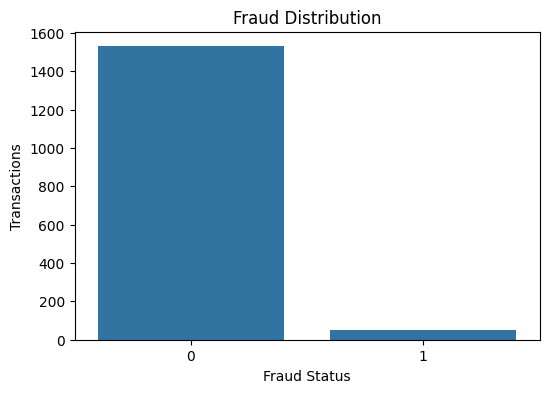

In [31]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="is_fraud"
)

plt.title("Fraud Distribution")
plt.xlabel("Fraud Status")
plt.ylabel("Transactions")

plt.show()

# 8. Transaction Amount Distribution

This visualization shows the distribution of transaction amounts.

It helps identify transaction value patterns and possible outliers.

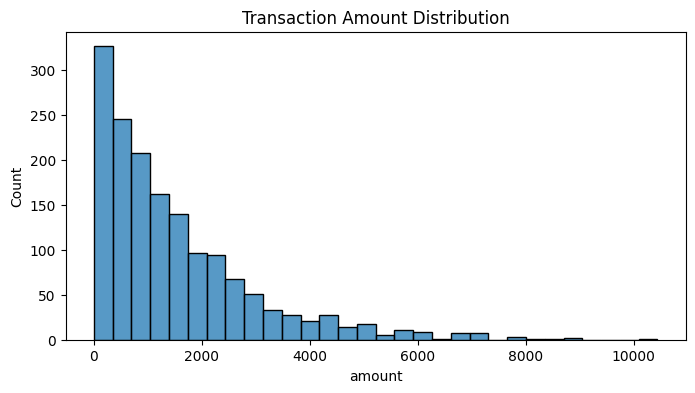

In [32]:
plt.figure(figsize=(8,4))

sns.histplot(
    data=df,
    x="amount",
    bins=30
)

plt.title("Transaction Amount Distribution")

plt.show()

# 9. Relationship Between Transaction Amount and Receiver Balance

A scatter plot is used to analyze the relationship between transaction amount and receiver balance after a transaction.

This helps identify possible relationships between input features and the target variable.

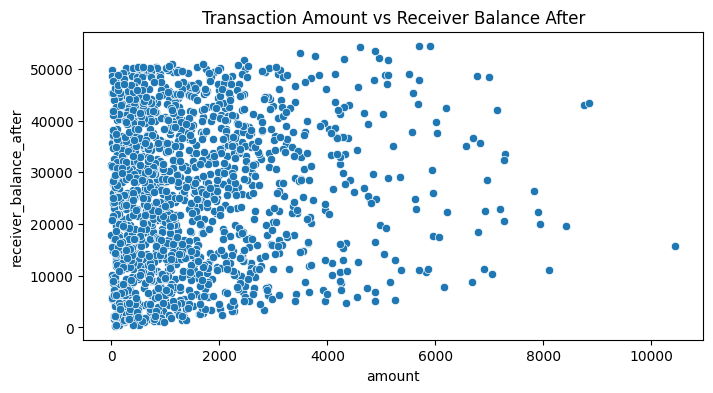

In [33]:
plt.figure(figsize=(8,4))

sns.scatterplot(
    data=df,
    x="amount",
    y="receiver_balance_after"
)

plt.title(
    "Transaction Amount vs Receiver Balance After"
)

plt.show()

# 10. Transaction Distribution by Region

This visualization shows the number of transactions across different regions.

It helps identify regional transaction patterns within the dataset.

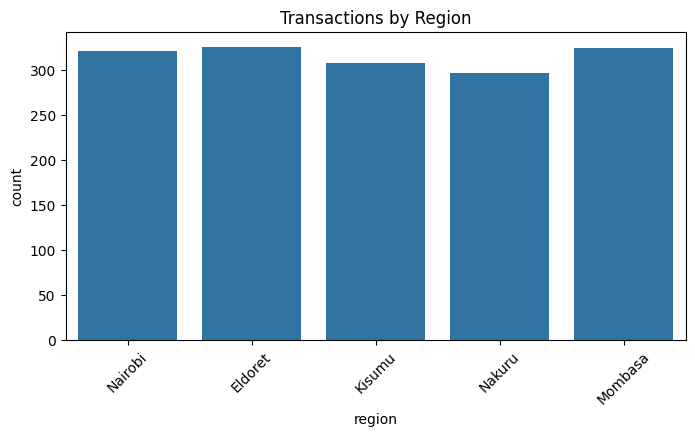

In [34]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    x="region"
)

plt.title("Transactions by Region")

plt.xticks(rotation=45)

plt.show()

# 11. Feature Engineering: Removing Transaction ID

The transaction ID column is removed because it is only an identifier and does not provide useful predictive information for machine learning.

In [35]:
df = df.drop(
    "transaction_id",
    axis=1
)


print("After removing transaction_id:")
df.head()

After removing transaction_id:


,amount,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,transaction_type,hour,month_2026,day_of_week,device_type,region,is_fraud
0,703.90,58586.32,57882.42,29932.92,30636.82,peer,14,1,Tue,smartphone,Nairobi,0
1,254.44,8088.00,7833.56,22962.44,23216.88,peer,18,10,Sat,feature,Eldoret,1
2,609.04,56675.00,56065.96,1029.22,1638.26,till,7,5,Thu,smartphone,Kisumu,0
3,5255.34,75090.36,69835.02,38.94,5294.28,paybill,11,2,Mon,smartphone,Nakuru,0
4,7282.67,24408.96,17126.29,26237.82,33520.49,till,0,7,Sat,smartphone,Nairobi,0


# 12. Encoding Categorical Features

Machine learning algorithms require numerical inputs.

Categorical variables are converted into numerical values using Scikit-Learn's LabelEncoder.

Encoded features:
- Transaction type
- Day of week
- Device type
- Region

In [37]:
df.dtypes

,0
amount,float64
sender_balance_before,float64
sender_balance_after,float64
receiver_balance_before,float64
receiver_balance_after,float64
transaction_type,int64
hour,int64
month_2026,int64
day_of_week,int64
device_type,int64


# 13. Verify Data Types

After encoding categorical variables, the dataset data types are checked to confirm that all features are in a suitable numerical format for machine learning.

In [38]:
X = df.drop(
    "receiver_balance_after",
    axis=1
)


y = df["receiver_balance_after"]


print("Features:")
X.head()

Features:


,amount,sender_balance_before,sender_balance_after,receiver_balance_before,transaction_type,hour,month_2026,day_of_week,device_type,region,is_fraud
0,703.90,58586.32,57882.42,29932.92,1,14,1,5,1,3,0
1,254.44,8088.00,7833.56,22962.44,1,18,10,2,0,0,1
2,609.04,56675.00,56065.96,1029.22,2,7,5,4,1,1,0
3,5255.34,75090.36,69835.02,38.94,0,11,2,1,1,4,0
4,7282.67,24408.96,17126.29,26237.82,2,0,7,2,1,3,0


# 14. Selecting Features and Target Variable

The dataset is divided into:

## Features (X)
Input variables used by the machine learning models.

## Target (y)
The variable the models learn to predict.

Target variable:
- Receiver balance after transaction

In [39]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)


print("Training Shape:")
print(X_train.shape)


print("Testing Shape:")
print(X_test.shape)

Training Shape:
(1262, 11)
Testing Shape:
(316, 11)


# 15. Splitting Training and Testing Data

The dataset is divided using Scikit-Learn's train_test_split function.

Split:
- 80% training data
- 20% testing data

The training set is used for learning patterns, while the testing set evaluates model performance.

In [40]:
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)


X_test_scaled = scaler.transform(
    X_test
)


print("Standardization completed successfully")

Standardization completed successfully


# 16. Feature Scaling

StandardScaler from Scikit-Learn is used to standardize numerical features.

Standardization improves model performance by placing features on a similar scale.

In [41]:
models = {


    "Linear Regression":

        LinearRegression(),



    "SGD Regression":

        SGDRegressor(

            max_iter=1000,

            learning_rate="constant",

            eta0=0.01,

            random_state=42

        ),



    "Decision Tree":

        DecisionTreeRegressor(

            random_state=42

        ),



    "Random Forest":

        RandomForestRegressor(

            n_estimators=100,

            random_state=42

        )

}


results = {}

# 17. Machine Learning Models

Four regression algorithms from Scikit-Learn are implemented:

1. Linear Regression
2. SGD Regression
3. Decision Tree Regression
4. Random Forest Regression

These models are trained to predict receiver balance after transactions.

In [42]:
for name, model in models.items():

    print("\nTraining:", name)


    model.fit(

        X_train_scaled,

        y_train

    )


    predictions = model.predict(

        X_test_scaled

    )


    mse = mean_squared_error(

        y_test,

        predictions

    )


    r2 = r2_score(

        y_test,

        predictions

    )


    results[name] = {

        "MSE": mse,

        "R2": r2,

        "model": model

    }


    print("MSE:", mse)

    print("R2 Score:", r2)


Training: Linear Regression
MSE: 1.3283889127086503e-22
R2 Score: 1.0

Training: SGD Regression
MSE: 2.2283406090484443
R2 Score: 0.9999999891084012

Training: Decision Tree
MSE: 786009.6325332277
R2 Score: 0.9961581718677675

Training: Random Forest
MSE: 378366.9912173499
R2 Score: 0.9981506321411328


# 18. Model Training and Evaluation

Each regression model is trained using the training dataset.

The models are evaluated using:

- Mean Squared Error (MSE)
- R² Score

The results are stored for comparison.

In [43]:
print("========== MODEL COMPARISON ==========")


for name, result in results.items():

    print(
        name,
        "Loss(MSE):",
        result["MSE"]
    )

========== MODEL COMPARISON ==========
Linear Regression Loss(MSE): 1.3283889127086503e-22
SGD Regression Loss(MSE): 2.2283406090484443
Decision Tree Loss(MSE): 786009.6325332277
Random Forest Loss(MSE): 378366.9912173499


# 19. Comparing Model Performance

The performance of all models is compared using their evaluation metrics.

The model with:
- Lowest MSE
- Highest R² Score

is considered the best-performing model.

In [44]:
results_df = pd.DataFrame({

    name:{
        "MSE":result["MSE"],
        "R2 Score":result["R2"]
    }

    for name,result in results.items()

}).T


results_df

,MSE,R2 Score
Linear Regression,1.328389e-22,1.000000
SGD Regression,2.228341e+00,1.000000
Decision Tree,7.860096e+05,0.996158
Random Forest,3.783670e+05,0.998151


# 20. Save Best Performing Model

The best model is selected based on the lowest Mean Squared Error.

The trained model and scaler are saved using Joblib:

- best_model.pkl
- scaler.pkl

These files allow future predictions without retraining the model.

In [45]:
best_model_name = min(
    results,
    key=lambda x: results[x]["MSE"]
)


best_model = results[best_model_name]["model"]


print("Best Model:")
print(best_model_name)



os.makedirs(
    "models",
    exist_ok=True
)



joblib.dump(
    best_model,
    "models/best_model.pkl"
)



joblib.dump(
    scaler,
    "models/scaler.pkl"
)



print("Model and scaler saved successfully")

Best Model:
Linear Regression
Model and scaler saved successfully
